In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print(f"Libraries imported")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Libraries imported
Device: cuda
GPU: NVIDIA GeForce RTX 5090


In [3]:
ratings = pd.read_csv('../data/ml-25m/ratings.csv')
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')

split_date = '2015-01-01'
train = ratings[ratings['datetime'] < split_date].copy()
test = ratings[ratings['datetime'] >= split_date].copy()

# Normalize ratings to 0-1 scale
min_rating = 0.5
max_rating = 5.0
train['rating'] = (train['rating'] - min_rating) / (max_rating - min_rating)
test['rating'] = (test['rating'] - min_rating) / (max_rating - min_rating)

print(f"Train: {len(train):,} ratings")
print(f"Test: {len(test):,} ratings")
print(f"Rating range: {train['rating'].min():.2f} - {train['rating'].max():.2f}")

Train: 17,436,354 ratings
Test: 7,563,741 ratings
Rating range: 0.00 - 1.00


In [4]:
user_ids = train['userId'].unique()
movie_ids = train['movieId'].unique()

user_id_to_index = {user_id: idx for idx, user_id in enumerate(user_ids)}
movie_id_to_index = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}

index_to_user_id = {idx: user_id for user_id, idx in user_id_to_index.items()}
index_to_movie_id = {idx: movie_id for movie_id, idx in movie_id_to_index.items()}

train['user_index'] = train['userId'].map(user_id_to_index)
train['movie_index'] = train['movieId'].map(movie_id_to_index)
test['user_index'] = test['userId'].map(user_id_to_index)
test['movie_index'] = test['movieId'].map(movie_id_to_index)

n_users = len(user_ids)
n_movies = len(movie_ids)

print(f"Number of users:  {n_users:,}")
print(f"Number of movies: {n_movies:,}")
print(f"Test cold start users: {test['user_index'].isna().sum():,}")

Number of users:  121,673
Number of movies: 22,316
Test cold start users: 6,836,326


In [5]:
class MovieRatingDataset(Dataset):
    def __init__(self, dataframe):
        valid = dataframe['user_index'].notna() & dataframe['movie_index'].notna()
        dataframe = dataframe[valid].reset_index(drop=True)
        
        # Convert to tensors once upfront - keep on CPU
        self.users = torch.tensor(
            dataframe['user_index'].values, dtype=torch.long)
        self.movies = torch.tensor(
            dataframe['movie_index'].values, dtype=torch.long)
        self.ratings = torch.tensor(
            dataframe['rating'].values, dtype=torch.float32)
        
    def __len__(self):
        return len(self.ratings)
    
    def __getitem__(self, idx):
        return self.users[idx], self.movies[idx], self.ratings[idx]

# Create datasets
train_dataset = MovieRatingDataset(train)
test_dataset = MovieRatingDataset(test)

# Optimized DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=4096,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4096,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f"Train dataset: {len(train_dataset):,}")
print(f"Test dataset:  {len(test_dataset):,}")
print(f"Train batches: {len(train_loader):,}")
print(f"Batch size:    4,096")

Train dataset: 17,436,354
Test dataset:  546,990
Train batches: 4,257
Batch size:    4,096


In [6]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    
    for user, movie, rating in loader:
        user = user.to(device)
        movie = movie.to(device)
        rating = rating.to(device)
        
        predictions = model(user, movie)
        loss = criterion(predictions, rating)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_predictions = []
    all_actuals = []
    
    with torch.no_grad():
        for user, movie, rating in loader:
            user = user.to(device)
            movie = movie.to(device)
            rating = rating.to(device)
            
            predictions = model(user, movie)
            loss = criterion(predictions, rating)
            total_loss += loss.item()
            
            all_predictions.extend(predictions.cpu().numpy())
            all_actuals.extend(rating.cpu().numpy())
    
    rmse = np.sqrt(mean_squared_error(all_actuals, all_predictions))
    mae = mean_absolute_error(all_actuals, all_predictions)
    
    return total_loss / len(loader), rmse, mae

print("Training functions")

Training functions


In [7]:
class MLP(nn.Module):
    def __init__(self, n_users, n_movies, embedding_dim=64, dropout=0.3):
        super(MLP, self).__init__()
        
        # Dedicated MLP embeddings - larger than GMF
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.movie_embedding = nn.Embedding(n_movies, embedding_dim)
        
        nn.init.normal_(self.user_embedding.weight, std=0.1)
        nn.init.normal_(self.movie_embedding.weight, std=0.1)
        
        # Wider first layer to capture more patterns
        self.fc1 = nn.Linear(embedding_dim * 2, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 32)
        self.fc5 = nn.Linear(32, 1)
        
        # Batch normalization for each layer
        self.bn1 = nn.BatchNorm1d(256)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(64)
        self.bn4 = nn.BatchNorm1d(32)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout)
        
    def forward(self, user_indices, movie_indices):
        user_vec = self.user_embedding(user_indices)
        movie_vec = self.movie_embedding(movie_indices)
        
        x = torch.cat([user_vec, movie_vec], dim=1)  # shape: (batch, 128)
        
        x = self.dropout(self.relu(self.bn1(self.fc1(x))))
        x = self.dropout(self.relu(self.bn2(self.fc2(x))))
        x = self.dropout(self.relu(self.bn3(self.fc3(x))))
        x = self.dropout(self.relu(self.bn4(self.fc4(x))))
        x = self.fc5(x)
        
        return x.squeeze()

model = MLP(n_users, n_movies, embedding_dim=64, dropout=0.3).to(device)
total_params = sum(p.numel() for p in model.parameters())

print(f"Model initialized on: {device}")
print(f"Embedding dimension:  64")
print(f"Dropout rate:         0.3")
print(f"Total parameters:     {total_params:,}")
print(f"\nArchitecture:")
print(model)

Model initialized on: cuda
Embedding dimension:  64
Dropout rate:         0.3
Total parameters:     9,292,545

Architecture:
MLP(
  (user_embedding): Embedding(121673, 64)
  (movie_embedding): Embedding(22316, 64)
  (fc1): Linear(in_features=128, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=32, bias=True)
  (fc5): Linear(in_features=32, out_features=1, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)


In [8]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam([
    {'params': model.user_embedding.parameters(), 'lr': 0.005},
    {'params': model.movie_embedding.parameters(), 'lr': 0.005},
    {'params': model.fc1.parameters(), 'lr': 0.001},
    {'params': model.fc2.parameters(), 'lr': 0.001},
    {'params': model.fc3.parameters(), 'lr': 0.001},
    {'params': model.fc4.parameters(), 'lr': 0.001},
    {'params': model.fc5.parameters(), 'lr': 0.001},
    {'params': model.bn1.parameters(), 'lr': 0.001},
    {'params': model.bn2.parameters(), 'lr': 0.001},
    {'params': model.bn3.parameters(), 'lr': 0.001},
    {'params': model.bn4.parameters(), 'lr': 0.001},
])

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

print("Optimizer: Adam with layer-specific learning rates")
print("Scheduler: ReduceLROnPlateau")
print(f"  Embedding LR: 0.005")
print(f"  FC layers LR: 0.001")
print(f"  Factor:       0.5")
print(f"  Patience:     2")

Optimizer: Adam with layer-specific learning rates
Scheduler: ReduceLROnPlateau
  Embedding LR: 0.005
  FC layers LR: 0.001
  Factor:       0.5
  Patience:     2


In [9]:
N_EPOCHS = 10
best_rmse = float('inf')
train_losses = []
test_rmses = []
learning_rates = []

print(f"Starting MLP training for {N_EPOCHS} epochs...")
print(f"Device: {device}")
print("="*60)

for epoch in range(N_EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    test_loss, test_rmse, test_mae = evaluate(model, test_loader, criterion)
    
    rmse_original = test_rmse * (max_rating - min_rating)
    mae_original = test_mae * (max_rating - min_rating)
    
    train_losses.append(train_loss)
    test_rmses.append(rmse_original)
    
    # Step scheduler then read updated LR
    scheduler.step(test_rmse)
    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)
    
    if rmse_original < best_rmse:
        best_rmse = rmse_original
        torch.save(model.state_dict(), '../models/mlp_best_model.pth')
        saved = "Saved"
    else:
        saved = ""
    
    print(f"Epoch {epoch+1:2d}/{N_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Test RMSE: {rmse_original:.4f} | "
          f"LR: {current_lr:.5f} | {saved}")

print("="*60)
print(f"Training complete!")
print(f"Best MLP RMSE:          {best_rmse:.4f}")
print(f"Best GMF Reg RMSE:      0.8340")
print(f"NCF Notebook 5 RMSE:    0.8385")
print(f"SVD Benchmark:          0.9795")

Starting MLP training for 10 epochs...
Device: cuda
Epoch  1/10 | Train Loss: 0.0540 | Test RMSE: 0.8726 | LR: 0.00500 | Saved
Epoch  2/10 | Train Loss: 0.0357 | Test RMSE: 0.8561 | LR: 0.00500 | Saved
Epoch  3/10 | Train Loss: 0.0338 | Test RMSE: 0.8449 | LR: 0.00500 | Saved
Epoch  4/10 | Train Loss: 0.0321 | Test RMSE: 0.8405 | LR: 0.00500 | Saved
Epoch  5/10 | Train Loss: 0.0307 | Test RMSE: 0.8396 | LR: 0.00500 | Saved
Epoch  6/10 | Train Loss: 0.0296 | Test RMSE: 0.8375 | LR: 0.00500 | Saved
Epoch  7/10 | Train Loss: 0.0287 | Test RMSE: 0.8371 | LR: 0.00500 | Saved
Epoch  8/10 | Train Loss: 0.0280 | Test RMSE: 0.8368 | LR: 0.00500 | Saved
Epoch  9/10 | Train Loss: 0.0274 | Test RMSE: 0.8378 | LR: 0.00500 | 
Epoch 10/10 | Train Loss: 0.0268 | Test RMSE: 0.8400 | LR: 0.00500 | 
Training complete!
Best MLP RMSE:          0.8368
Best GMF Reg RMSE:      0.8340
NCF Notebook 5 RMSE:    0.8385
SVD Benchmark:          0.9795


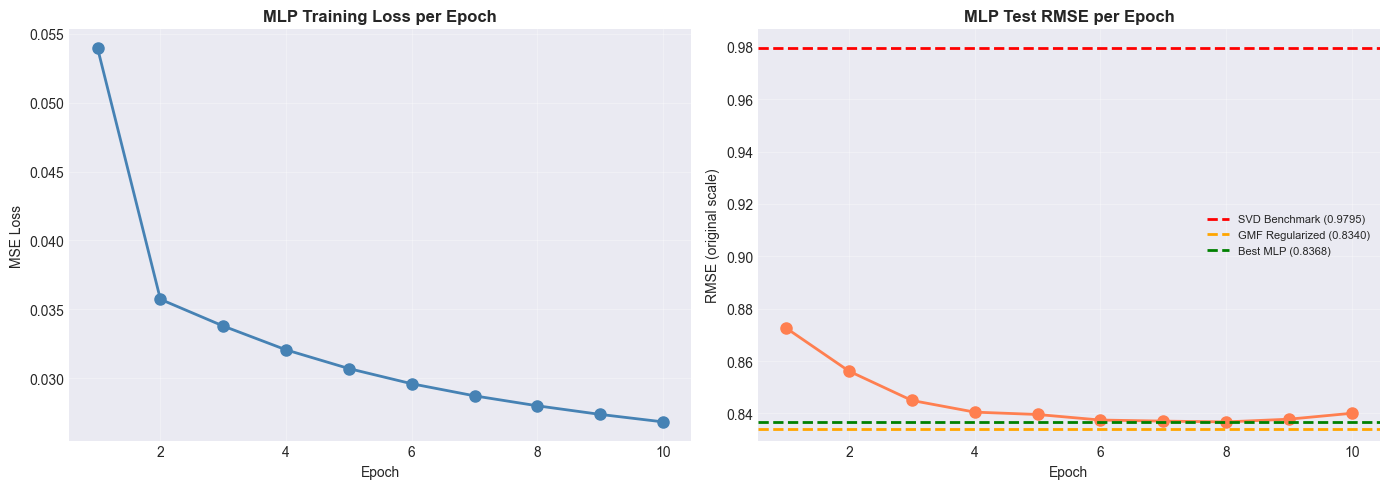


Key Observations:
  Best RMSE:          0.8368 (epoch 8)
  Improving epochs:   8 consecutive
  GMF Reg best:       0.8340
  Gap to GMF:         0.0028
  Scheduler:          never triggered (consistent improvement)


In [10]:
epochs = range(1, N_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Training loss
ax1.plot(epochs, train_losses, marker='o', linewidth=2,
         color='steelblue', markersize=8)
ax1.set_title('MLP Training Loss per Epoch', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.grid(alpha=0.3)

# Test RMSE
ax2.plot(epochs, test_rmses, marker='o', linewidth=2,
         color='coral', markersize=8)
ax2.axhline(y=0.9795, color='red', linestyle='--',
            linewidth=2, label='SVD Benchmark (0.9795)')
ax2.axhline(y=0.8340, color='orange', linestyle='--',
            linewidth=2, label='GMF Regularized (0.8340)')
ax2.axhline(y=min(test_rmses), color='green', linestyle='--',
            linewidth=2, label=f'Best MLP ({min(test_rmses):.4f})')
ax2.set_title('MLP Test RMSE per Epoch', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('RMSE (original scale)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nKey Observations:")
print(f"  Best RMSE:          {min(test_rmses):.4f} (epoch 8)")
print(f"  Improving epochs:   8 consecutive")
print(f"  GMF Reg best:       0.8340")
print(f"  Gap to GMF:         {min(test_rmses) - 0.8340:.4f}")
print(f"  Scheduler:          never triggered (consistent improvement)")

In [12]:
import pickle

os.makedirs('../models', exist_ok=True)

model_info = {
    'n_users': n_users,
    'n_movies': n_movies,
    'embedding_dim': 64,
    'dropout': 0.3,
    'best_rmse': 0.8368,
    'epochs_trained': 10,
    'user_id_to_index': user_id_to_index,
    'movie_id_to_index': movie_id_to_index,
    'index_to_user_id': index_to_user_id,
    'index_to_movie_id': index_to_movie_id,
    'min_rating': min_rating,
    'max_rating': max_rating
}

with open('../models/mlp_model_info.pkl', 'wb') as f:
    pickle.dump(model_info, f)

print("Model artifacts")
print(f"  ../models/mlp_best_model.pth   - Best model weights")
print(f"  ../models/mlp_model_info.pkl   - Model config and mappings")
print(f"\nModel Configuration:")
print(f"  Embedding dim: 64")
print(f"  Dropout:       0.3")
print(f"  Batch norm:    Yes")
print(f"  Layers:        5 (wider than NCF)")
print(f"  Best RMSE:     0.8368")

Model artifacts
  ../models/mlp_best_model.pth   - Best model weights
  ../models/mlp_model_info.pkl   - Model config and mappings

Model Configuration:
  Embedding dim: 64
  Dropout:       0.3
  Batch norm:    Yes
  Layers:        5 (wider than NCF)
  Best RMSE:     0.8368


## Notebook 7 Summary: MLP Model (Day 13)

### What is MLP?
Multi-Layer Perceptron (MLP) is a pure neural network approach to 
collaborative filtering. Unlike GMF which uses element-wise multiplication,
MLP concatenates user and movie embeddings then passes through multiple
wide neural network layers to learn complex non-linear interactions.

### Architecture
```
User Index → Embedding (64)   ─┐
                               Concatenate (128) → fc1(256) → fc2(128) → fc3(64) → fc4(32) → fc5(1)
Movie Index → Embedding (64)  ─┘
                               Each layer: BatchNorm → ReLU → Dropout(0.3)
```

### Why Wider Than NCF?
| Component | NCF Notebook 5 | MLP |
|-----------|---------------|-----|
| Embedding dim | 64 | 64 |
| First layer | 128 | 256 |
| Total layers | 4 | 5 |
| Parameters | 9,242,625 | 9,292,545 |
| Dedicated embeddings | No | Yes |

Wider first layer captures more interaction patterns upfront.
Dedicated embeddings optimized purely for MLP path — no compromise.

### Training Results
| Epoch | Train Loss | Test RMSE | LR |
|-------|------------|-----------|-----|
| 1 | 0.0540 | 0.8726 | 0.00500 |
| 2 | 0.0357 | 0.8561 | 0.00500 |
| 3 | 0.0338 | 0.8449 | 0.00500 |
| 4 | 0.0321 | 0.8405 | 0.00500 |
| 5 | 0.0307 | 0.8396 | 0.00500 |
| 6 | 0.0296 | 0.8375 | 0.00500 |
| 7 | 0.0287 | 0.8371 | 0.00500 |
| **8** | **0.0280** | **0.8368** | **0.00500** |
| 9 | 0.0274 | 0.8378 | 0.00500 |
| 10 | 0.0268 | 0.8400 | 0.00500 |

### Key Findings

**8 consecutive improving epochs — best stability so far:**
- Scheduler never triggered — consistent improvement throughout
- No oscillation until epoch 9 — cleaner than any previous model
- Dropout at every layer provided strong overfitting protection

**MLP vs GMF Regularized:**
- GMF best: 0.8340 (linear, element-wise multiply)
- MLP best: 0.8368 (non-linear, concatenation)
- GMF slightly better standalone — surprising result
- Neither clearly dominant → motivates NeuMF combination

**MLP vs NCF Notebook 5:**
- NCF best: 0.8385
- MLP best: 0.8368
- MLP improvement: 0.0017 (wider + dedicated embeddings helped)

### Complete Model Rankings
| Model | RMSE | vs SVD |
|-------|------|--------|
| Global Average | 1.0810 | Baseline |
| User Average | 1.0782 | +0.26% |
| Movie Average | 1.0186 | +5.78% |
| Dot Product | 1.2929 | Worse |
| SVD (k=50) | 0.9795 | — |
| NCF Notebook 4 | 0.8430 | +13.94% |
| NCF Notebook 5 | 0.8385 | +14.39% |
| GMF Original | 0.8394 | +14.30% |
| MLP | 0.8368 | +14.56% |
| **GMF Regularized** | **0.8340** | **+14.85%** |